# **DESARROLLO DE UN PIPELINE ANALÍTICO-PREDICTIVO PARA LA ESTIMACIÓN DINÁMICA DEL RENDIMIENTO DE BIOETANOL BASADO EN CINÉTICA FERMENTATIVA DE MUCÍLAGO DE CACAO ( *Theobroma cacao L.* ) CCN-51 Y NACIONAL**

Este Pipeline de Machine Learning está diseñado para predecir con alta precisión el rendimiento real de bioetanol a partir del mucílago de cacao (Theobroma cacao L.), integrando descriptores bioquímicos y algoritmos de gradiente boosting.

Se consideraron dos variedades comerciales producidas en la región litoral del Ecuador, con énfasis en las cuatro provincias que concentran el 75% de la producción nacional: Guayas, Los Ríos, Esmeraldas y Manabí. El modelo sigue un enfoque de regresión supervisada, donde la variable objetivo es de naturaleza continua y corresponde a la concentración de etanol, expresada en porcentaje volumen/volumen (% v/v), medida al finalizar el proceso fermentativo.

In [3]:
# Importamos las principales librerias
import unicodedata
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

In [4]:
# Importación de datos
datos = pd.read_csv('data_mucilago.csv')

## **Análisis Exploratorio de Datos (EDA)**

In [5]:
#Visualizamos los 5 primeros registros del dataset
datos.head()

,provincia,variedad,brix,ph_inicial,temperatura_c,etanol_vv
0,ESMERALDAS,nacional fino,15.7,"3,52",26.2,3.96
1,LosRios_Ec,ccn51,26.1,4.52,26.0,7.19
2,ESM-ER,nacional,22.2,5.44,36.5,6.93
3,LosRios_Ec,Nac. Fino,19.8,5.05,26.0,4.80
4,Los Rios,nacional fino,11.8,5.26,26.4,2.83


Una vista previa de los registros del dataset permite identificar posibles correcciones de escritura o formatos para evitar errores de redundancia al modelo.

In [10]:
#Identificamos y enlistamos las columnas numéricas con formato y datos erróneos
col_sucias = ['brix', 'ph_inicial', 'temperatura_c']

In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   provincia      1000 non-null   object 
 1   variedad       1000 non-null   object 
 2   brix           1000 non-null   float64
 3   ph_inicial     1000 non-null   object 
 4   temperatura_c  1000 non-null   float64
 5   etanol_vv      1000 non-null   float64
dtypes: float64(3), object(3)
memory usage: 47.0+ KB


**Observación**

 Se evidencia registros de tipo númerico con Dtype (tipo de formato) Object . Por ello se procede a su corrección previo al diseño del modelo de aprendizaje automático.

In [8]:
#Eliminamos los posibles duplicados en el dataset
print(f"El total de registros del dataset previo a la eliminación de datos duplicados es: {datos.shape[0]}")
datos.drop_duplicates(inplace=True)
print(f"El total de registros del dataset posterior a la eliminación de datos duplicados es: {datos.shape[0]}")

El total de registros del dataset previo a la eliminación de datos duplicados es: 1000
El total de registros del dataset posterior a la eliminación de datos duplicados es: 1000


In [11]:
# Usamos la función apply() y empleamos un lambda para corregir de forma inmediata los datos numéricos erróneos
datos[col_sucias] = datos[col_sucias].apply(lambda x: pd.to_numeric(x.astype(str).str.replace(",",".")\
                                     .str.extract(r'(\d+\.?\d*)')[0], errors='coerce'))

In [12]:
# Confirmamos las correciones del formato (Dtype) de los datos numéricos.
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   provincia      1000 non-null   object 
 1   variedad       1000 non-null   object 
 2   brix           1000 non-null   float64
 3   ph_inicial     1000 non-null   float64
 4   temperatura_c  1000 non-null   float64
 5   etanol_vv      1000 non-null   float64
dtypes: float64(4), object(2)
memory usage: 47.0+ KB


In [13]:
datos.head()

,provincia,variedad,brix,ph_inicial,temperatura_c,etanol_vv
0,ESMERALDAS,nacional fino,15.7,3.52,26.2,3.96
1,LosRios_Ec,ccn51,26.1,4.52,26.0,7.19
2,ESM-ER,nacional,22.2,5.44,36.5,6.93
3,LosRios_Ec,Nac. Fino,19.8,5.05,26.0,4.80
4,Los Rios,nacional fino,11.8,5.26,26.4,2.83


## **Data Engineering de Variables Categóricas**

In [14]:
#Del dataset dividiremos los registros según el tipo de variable sea numéricos o categóricos
#Variables Categóricas
categoricos = datos.select_dtypes(include=['object']).columns.tolist()
categoricos

['provincia', 'variedad']

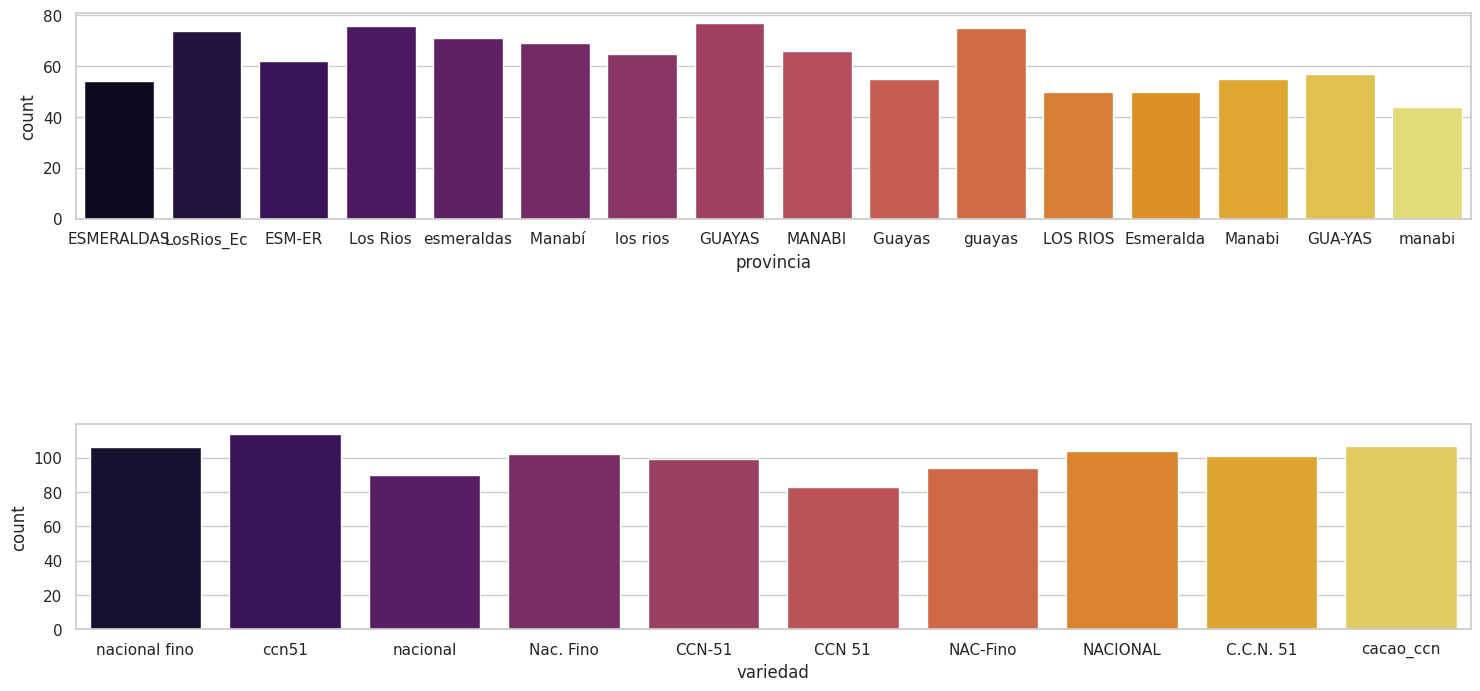

In [15]:
#Procedemos a ver la frecuencia de los datos categoricos en las distintas columnas mediante countplots.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(18,8))
plt.subplots_adjust(hspace=1)
for i, col in enumerate(categoricos):
  sns.countplot(data=datos, x=col, palette='inferno', hue=col, ax=ax[i])

**Observación**
Se observan datos repetidos con variaciones en su escritura en ambas columnas. Sino se corrige el modelo interpretaria cada una como una categoría distinta y, en consecuencia, aprende patrones incorrectos.

In [16]:
#Este código abreviado con apply() + lambda: x, eliminamos las variaciones de un dato categórico en un estándar de minúsculas sin espacios para el modelo.
datos[categoricos] = datos[categoricos].apply(lambda x: x.str.normalize('NFKD').str.encode('ascii', errors='ignore')\
                                       .str.decode('utf-8').str.lower().str.strip().str.replace(" ","_"))

In [17]:
# Recorremos los valores de las columnas categóricas con un bucle para identificar otro tipo de errores o variaciones en sus registros.
for col in datos[categoricos].columns:
  print("======="*30)
  print(datos[col].value_counts())

provincia
manabi        234
guayas        207
los_rios      191
esmeraldas    125
losrios_ec     74
esm-er         62
gua-yas        57
esmeralda      50
Name: count, dtype: int64
variedad
nacional         194
ccn51            114
cacao_ccn        107
nacional_fino    106
nac._fino        102
c.c.n._51        101
ccn-51            99
nac-fino          94
ccn_51            83
Name: count, dtype: int64


In [18]:
# Unimos datos corrigiendo los errores tipográficos en los registros de la columna provincia
datos.loc[datos['provincia']=='losrios_ec','provincia'] = 'los_rios'
datos.loc[datos['provincia']=='esm-er', 'provincia'] = 'esmeraldas'
datos.loc[datos['provincia']=='gua-yas', 'provincia'] = 'guayas'
datos.loc[datos['provincia']=='esmeralda', 'provincia'] = 'esmeraldas'

In [19]:
# Unimos datos corrigiendo los errores tipográficos en los registros de la columna variedad
datos.loc[datos['variedad']=='ccn51','variedad'] = 'ccn_51'
datos.loc[datos['variedad']=='cacao_ccn', 'variedad'] = 'ccn_51'
datos.loc[datos['variedad']=='nacional_fino','variedad'] = 'nacional'
datos.loc[datos['variedad']=='nac._fino', 'variedad'] = 'nacional'
datos.loc[datos['variedad']=='c.c.n._51','variedad'] = 'ccn_51'
datos.loc[datos['variedad']=='ccn-51','variedad'] = 'ccn_51'
datos.loc[datos['variedad']=='nac-fino', 'variedad'] = 'nacional'

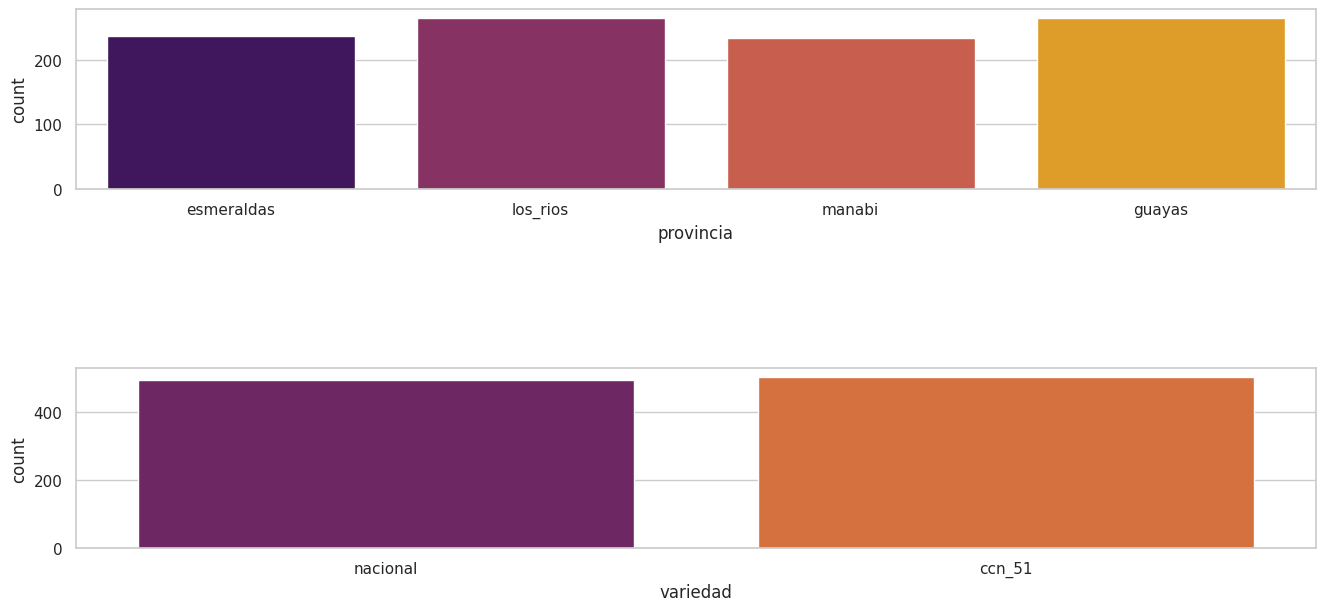

In [20]:
# Verificamos como se reduce el número de barras con respecto a la frecuencia de un registro mediante otro countplot.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16,7))
plt.subplots_adjust(hspace=1)
for i, col in enumerate(categoricos):
  sns.countplot(data=datos, x=col, palette='inferno', hue=col, ax=ax[i])

In [21]:
# Imprimimos la proporción (%) de los registos categóricos
for col in datos[categoricos].columns:
  print("======="*30)
  print(datos[col].value_counts(normalize=True)*100)

provincia
los_rios      26.5
guayas        26.4
esmeraldas    23.7
manabi        23.4
Name: proportion, dtype: float64
variedad
ccn_51      50.4
nacional    49.6
Name: proportion, dtype: float64


In [22]:
#Identificamos los registros nulos en las variables categóricas
datos[categoricos].isna().sum()

,0
provincia,0
variedad,0


In [23]:
#Conteo de registros por variable(columna) categórica
for col in categoricos:
  print(f"La columna {col} tiene registrado únicamente un total de {datos[col].nunique()} elementos")

La columna provincia tiene registrado únicamente un total de 4 elementos
La columna variedad tiene registrado únicamente un total de 2 elementos


## **Data Engineering de Variables Numéricas**

In [25]:
#Variables numéricas
numericos = datos.select_dtypes(exclude=['object']).columns.tolist()

In [24]:
#El data engineer de las variables numéricas siempre parte con el análisis del resumen estadístico.
print(datos.describe().round(3)) #la función describe() nos permite visualizar los parámetros estadísticas más importantes.

           brix  ph_inicial  temperatura_c  etanol_vv
count  1000.000    1000.000       1000.000   1000.000
mean     17.824       4.420         30.148      5.239
std       5.259       0.818          5.940      1.700
min       9.100       3.010         14.000      2.030
25%      13.275       3.678         26.000      3.818
50%      17.950       4.450         30.050      5.095
75%      22.400       5.130         34.300      6.460
max      27.000       5.800         52.000      9.250


**Boxplot**
El boxplot (o diagrama de caja y bigotes) es la herramienta estándar de oro para la detección visual de outliers, especialmente porque se basa en la Estadística Robusta (Rango Intercuartílico).

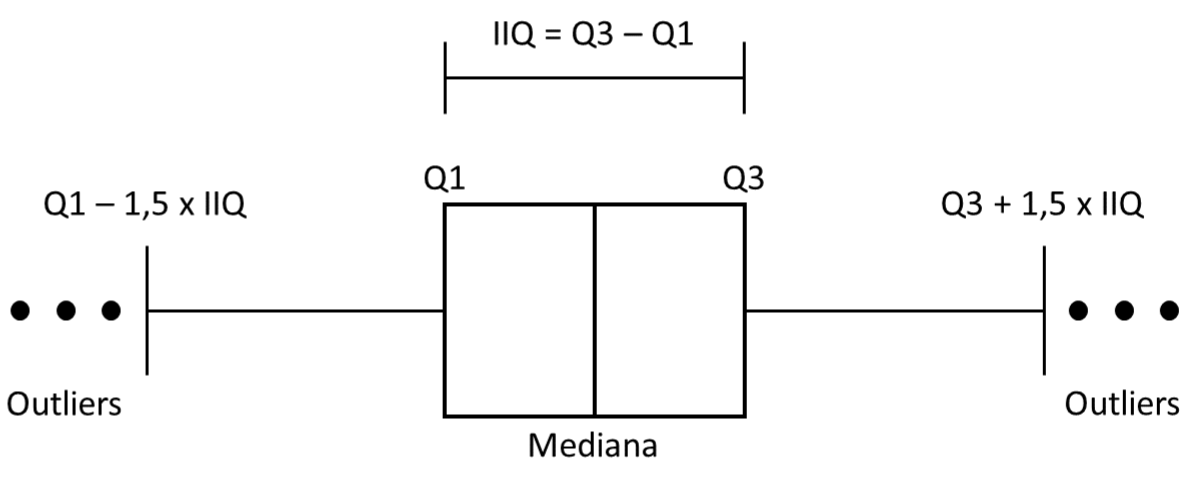

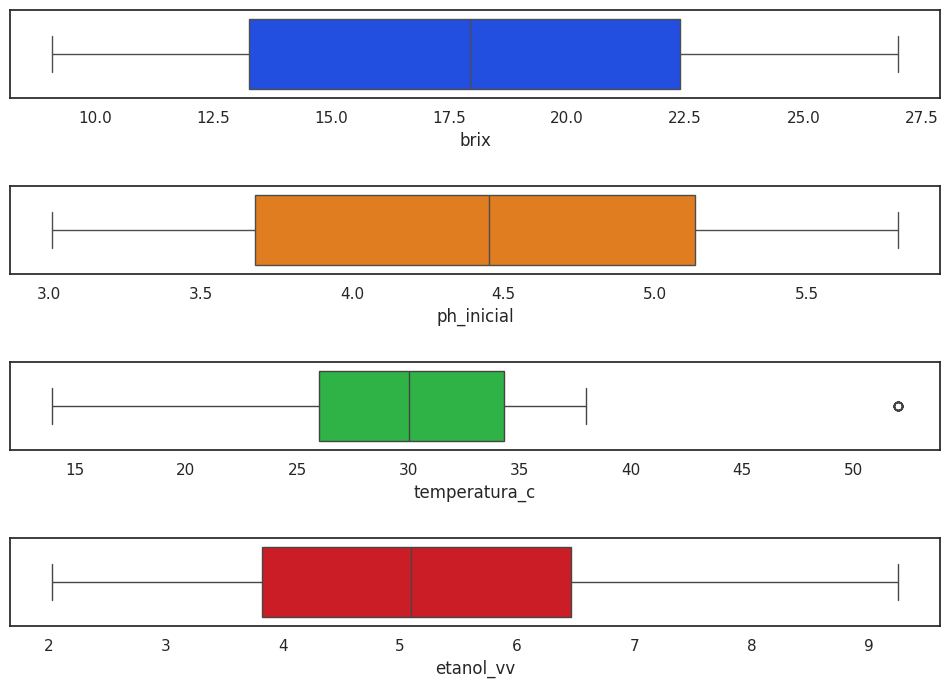

In [26]:
#Identificamos outliers con boxplots por variable (columna)
sns.set_theme(style='white')
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(12,8))
plt.subplots_adjust(hspace=1)
for i, col in enumerate(numericos):
  colores = sns.color_palette('bright', n_colors=len(numericos))
  sns.boxplot(data=datos, x=col, color=colores[i], ax=ax[i])

**Observación:** Visualemtente solo se observa valores atípicos en el boxplot de la columna 'temperatura_c'. Los mismos serán manejados con el método de Tukey.

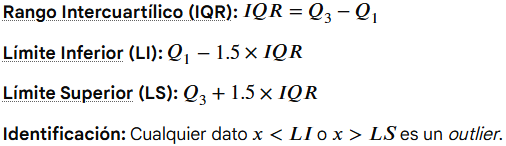

In [27]:
# Manejo de Outliers con Método de Tukey
temp = datos['temperatura_c']
Q1 = temp.quantile(0.25)
Q3 = temp.quantile(0.75)
IQR = Q3 - Q1
LIM_INF = Q1 - IQR*1.5
LIM_SUP = Q3 + IQR*1.5

In [28]:
#Una manera más técnica de manejar valores atípicos es convertirlos a NULOS para luego imputar y no perder información.
datos['temperatura_c'] =  datos['temperatura_c'].mask((datos['temperatura_c']<LIM_INF) | (datos['temperatura_c']>LIM_SUP)) # Enmascaramos los valores atípicos a NaN

**Nota:** Una regla de oro al momento de manejar outliers es la no eliminación de los mismos, debido a la perdida de información valiosa que le podría resultar util al modelo, ante esto se puede optar por convertirlos a valores no numéricos (NaN) o vacíos (Null), para posteriormente usar técnicas de imputación.

In [29]:
# Visualizamos los outliers
print(datos[numericos].isna().sum())

brix              0
ph_inicial        0
temperatura_c    19
etanol_vv         0
dtype: int64


In [30]:
# Imputamos con el método MICE (Imputación múltiple por ecuaciones encadenadas)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [31]:
imputador = IterativeImputer(max_iter=10, random_state=0)
datos[numericos] = imputador.fit_transform(datos[numericos])

In [32]:
# Verificamos que la imputación fue un éxito
print(datos[numericos].isna().sum())

brix             0
ph_inicial       0
temperatura_c    0
etanol_vv        0
dtype: int64


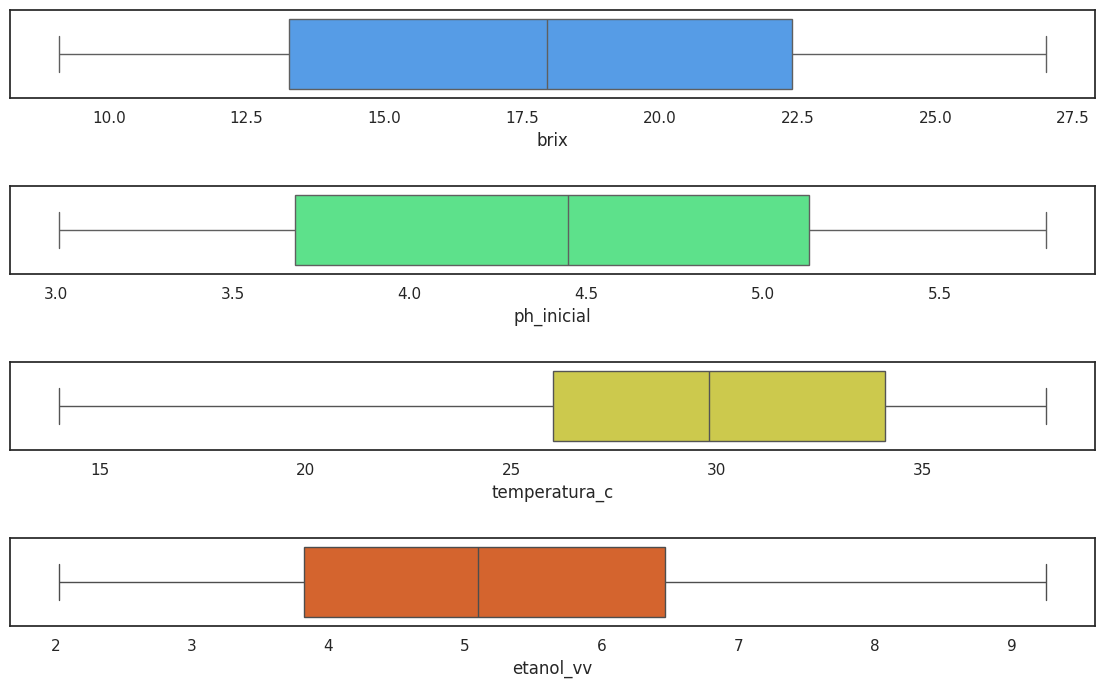

In [33]:
#Nuevamente graficamos y evidenciamos que enmascaramos los outliers con valores nulos.
sns.set_theme(style='white')
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(14,8))
plt.subplots_adjust(hspace=1)
colores = sns.color_palette('turbo', n_colors=len(numericos))
for i, col in enumerate(numericos):
  sns.boxplot(data=datos,x=col, color=colores[i], ax=ax[i])

In [34]:
# Verificamos los datos numéricos antes de pasar al análisis estadístico
print(datos[numericos].describe().T.round(2))

                count   mean   std    min    25%    50%    75%    max
brix           1000.0  17.82  5.26   9.10  13.28  17.95  22.40  27.00
ph_inicial     1000.0   4.42  0.82   3.01   3.68   4.45   5.13   5.80
temperatura_c  1000.0  29.73  5.10  14.00  26.00  29.80  34.10  38.00
etanol_vv      1000.0   5.24  1.70   2.03   3.82   5.10   6.46   9.25


### **Feature Engineering**

In [35]:
# Una vez limpio los datos añadimos el ratio entre los grados brix y el pH inicial
indice_y = datos.columns.get_loc('etanol_vv') # Identificamos la posición de la variable objetivo
datos.insert(loc=indice_y, column='brix_ph', value=datos['brix']/datos['ph_inicial']) #Insetamos la columna nueva con el cálculo del ratio

In [36]:
# Creamos nuevamente el conjunto de datos numéricos e integramos la nueva variable
numericos = datos.select_dtypes(exclude=['object']).columns.tolist()

**Nota:**
Esta variable aporta información que ninguna de las dos variables por separado captura. La relación entre disponibilidad de sustrato y acidez del medio en un solo número útil para los modelos.

## **Análisis Estadístico de Variables**

In [37]:
# Librerias empleadas en el análisis estadístico
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
import scipy.stats as st

### **Chi Cuadrado**

La prueba Chi-cuadrado de independencia es una **validación de la aleatoriedad** que nos asegura que cualquier variación en el rendimiento del bioetanol que veamos más adelante no será un subproducto de una mala distribución de las muestras por región.

In [38]:
tabla4x2 = pd.crosstab(datos['provincia'], datos['variedad'])
print(f"{'*'*8} TABLA 4 x 2 {'*'*8}")
print(tabla4x2)

******** TABLA 4 x 2 ********
variedad    ccn_51  nacional
provincia                   
esmeraldas     115       122
guayas         141       123
los_rios       139       126
manabi         109       125


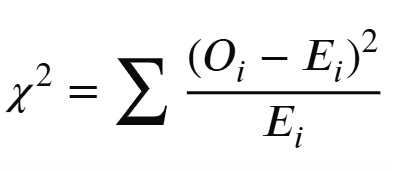

In [39]:
chi2, p , dof, expected = chi2_contingency(tabla4x2)
print(f"Chi2: {chi2:.3f}")
print(f"El valor de P: {p:.5f} --> {'Las variables estan asociadas.' if p<0.05 else 'Las variables no estan asociadas.'}\
    \n{'Existe un dependencia estadística por ello se rechaza la hipótesis nula (H0).' if p<0.05 else 'No existe dependencia estadística por ello no se rechaza la hipótesis nula (H0).'}")

Chi2: 3.102
El valor de P: 0.37617 --> Las variables no estan asociadas.    
No existe dependencia estadística por ello no se rechaza la hipótesis nula (H0).


**Ausencia de Sesgo Geográfico:** Esto es positivo para el modelo de Machine Learning. Significa que el algoritmo no "aprenderá" reglas falsas como "si es de Guayas, fijo es CCN-51". Los datos están bien balanceados espacialmente.

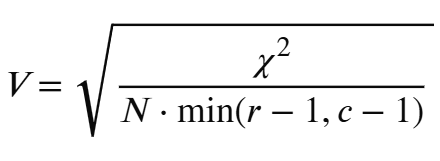

In [40]:
chi2 = 3.102
n = 1000
rows, cols = 4, 2

# El denominador es el mínimo entre (filas-1) y (columnas-1)
phi_c = np.sqrt(chi2 / (n * min(rows - 1, cols - 1)))

print(f"V de Cramer: {phi_c:.4f}")

V de Cramer: 0.0557


**Interpretación**

**V de Cramer:** Dado que el Chi2 es bajo (3.102), la fuerza de asociación es despreciable. Confirmamos que la procedencia no condiciona la genética del material recolectado en este estudio.

### **Mínimo Cuadrados Ordinarios (MCO)**

**Nota**

statsmodels aplica lo que se llama como
*codificación por contraste* (**Treatment coding**)
*  Elige una categoría base (referencia)
*  Omite esa categoría
*  Crea dummies para las demás

In [41]:
# Para poder añadir variables categóricas usamos C()
modelo = ols('etanol_vv ~ brix + temperatura_c + ph_inicial + brix_ph + C(provincia) + C(variedad)', data=datos).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              etanol_vv   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     605.6
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:39:01   Log-Likelihood:                -1062.4
No. Observations:                1000   AIC:                             2143.
Df Residuals:                     991   BIC:                             2187.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

**Interpretación**

* **Bondad de Ajuste (R2 ≈ 0.83)**: El modelo explica el 83% de la variabilidad del etanol. Es un ajuste lineal robusto para datos biológicos.
* **Dominancia del Brix:** El coeficiente de 0.2897 (p<0.000) confirma que el contenido de sólidos solubles es el motor principal del rendimiento. Técnicamente, esto valida que la ruta metabólica de la levadura está respondiendo proporcionalmente a la disponibilidad de sustrato (azúcar).

* **Irrelevancia Lineal de Temperatura y pH:** Con p-valores de 0.797 y 0.489.  No son significativos aquí.

* **Factores Categóricos (Provincia/Variedad):** Siguen sin ser significativos en la media. Esto sugiere que el CCN-51 y el Nacional tienen rendimientos promedio similares si los grados Brix son iguales. La diferencia real entre variedades probablemente esté en cuánto Brix logran acumular en campo, no en su eficiencia de conversión química.

* **Estadístico de Jarque-Bera (JB):** Bajó ligeramente, pero sigue indicando no normalidad (p=0.0009).
* **Durbin-Watson (1.948):** Casi perfecto (cerca de 2). No hay autocorrelación de residuos; sus observaciones son independientes.

* **Cond. No. (673):** Está algo elevado. Indica que hay multicolinealidad (esperable, ya que insertamos el ratio que depende directamente del Brix.


### **ANOVA**

**Importante**

Debemos considerar realizar la prueba de Levene para ver si existe homocedasticidad entre las varianzas de los distintos grupos (p-valor>0.05), Si es menor, el ANOVA podría estar dándote resultados falsos porque un grupo es mucho más "volátil" que el otro, por ende requerira prueba **no paramétrica** (Kruskal-Wallis).

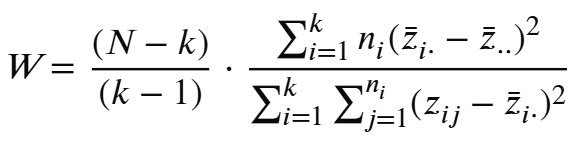

In [42]:
#Establecemos los grupos para verificar que existe homocedasticidad
grupo_ccn51 = datos[datos['variedad']=='ccn_51']['etanol_vv']
grupo_nacional = datos[datos['variedad']=='nacional']['etanol_vv']
_,p_lev = st.levene(grupo_ccn51,grupo_nacional)
print(f"Homocedasticidad (Levene): {p_lev:.5f} --> {'Las varianzas son iguales' if p_lev>0.05 else 'Al menos una varianza es diferente'}")

Homocedasticidad (Levene): 0.68073 --> Las varianzas son iguales


**Interpretación**

La homocedasticidad  de los grupos muestra estadísticamente que las medias de todas las provincias y variedades pertenecen a la misma "población" en cuanto a su capacidad de producción.

**Interpretación:**

No existe evidencia suficiente para rechazar la hipótesis nula (H0). Se confirma la homocedasticidad (igualdad de varianzas) con un p Levene de 0.6807 superior a 0.05, lo que permite proceder con un ANOVA de Fisher estándar para comparar las medias de rendimiento entre CCN-51 y Nacional.

**Nota**

Lo importante es PR(>F) (p-value)
* p < 0.05 → variable significativa ✔
* p > 0.05 → no significativa ❌

In [43]:
tabla_anova = anova_lm(modelo, typ=2).round(3)
print(f"{'*'*18} TABLA ANOVA {'*'*18}")
print('\n',tabla_anova)

****************** TABLA ANOVA ******************

                 sum_sq     df        F  PR(>F)
C(provincia)     0.543    3.0    0.366   0.778
C(variedad)      0.003    1.0    0.005   0.943
brix           106.897    1.0  216.156   0.000
temperatura_c    0.033    1.0    0.066   0.797
ph_inicial       0.237    1.0    0.478   0.489
brix_ph          0.028    1.0    0.056   0.813
Residual       490.087  991.0      NaN     NaN


**Interpretación:**

El análisis confirma una jerarquía de predictores donde el Brix domina la explicación del fenómeno (F=216.15, p<0.001). Los factores categóricos (Provincia y Variedad) y las variables fisicoquímicas secundarias (pH, Temperatura) no presentan significancia estadística, ratificando la homogeneidad del proceso de fermentación independientemente del origen o la genética del cacao.

**Distribución de los Residuos (Errores) - Prueba Shapiro-Wilk**

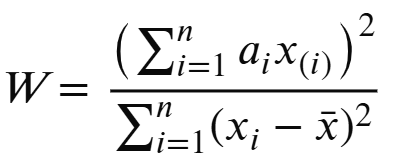

In [44]:
# Distribución de los residuos (Los errores del modelo)
_,p_shap = st.shapiro(modelo.resid)
print(f"Normalidad (Shapiro-Wilk): {p_shap:.5f} --> {'Los residuos siguen una distribución normal' if p_shap>0.05 else 'Los residuos no siguen una distribución normal'}")

Normalidad (Shapiro-Wilk): 0.00012 --> Los residuos no siguen una distribución normal


Text(0.5, 1.0, 'Distribución de Residuos del Modelo ANOVA')

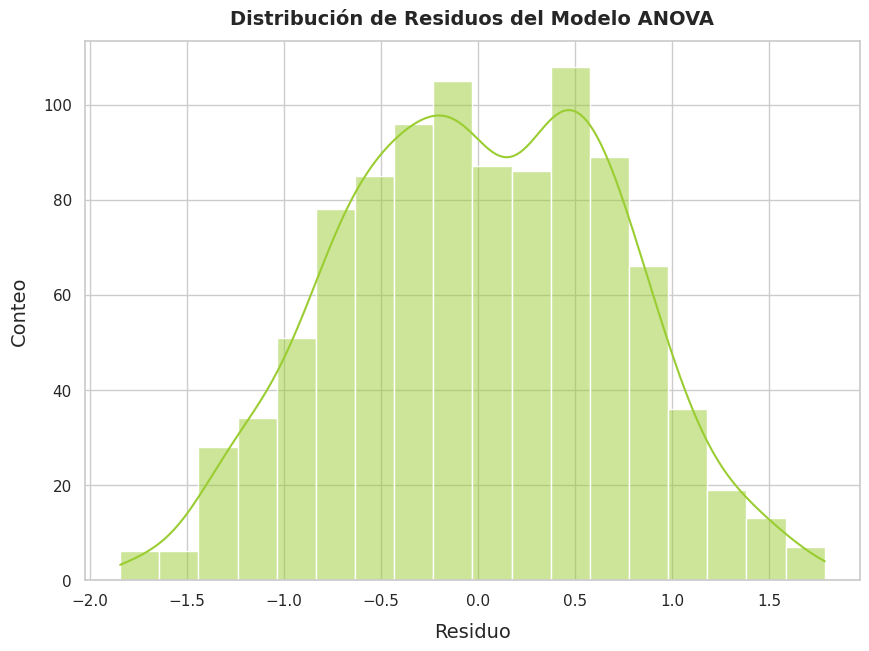

In [45]:
# Gráfica de la distribución de los residuos
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10,7))
ax = sns.histplot(modelo.resid, color='yellowgreen', kde=True) #Residuo = Valor real - Valor predicho
plt.xlabel('Residuo', fontsize=14, labelpad=10)
plt.ylabel('Conteo', fontsize=14, labelpad=10)
plt.title("Distribución de Residuos del Modelo ANOVA", pad=12, fontsize=14, fontweight='bold')

**La Gráfica (Histograma + KDE):** Se observa una distribución bimodal (dos picos). Esto indica que el modelo no está capturando un factor que divide los datos en dos grupos o que existe una relación no lineal que el ANOVA/OLS simple ignora.

### **Test Post Hoc**

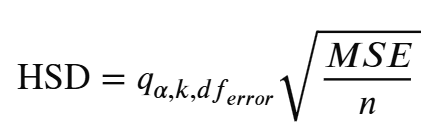

In [46]:
print(f"{'*'*20} PRUEBA DE TUKEY {'*'*20}")
print(f"\n{'-'*18} Variedades de Cacao {'-'*18}")
print('\n',pairwise_tukeyhsd(endog=datos['etanol_vv'], groups=datos['variedad'], alpha=0.05))
print(f"\n{'-'*12} Provincias Productoras (Origen) {'-'*13}")
print('\n',pairwise_tukeyhsd(endog=datos['etanol_vv'], groups=datos['provincia'], alpha=0.05))

******************** PRUEBA DE TUKEY ********************

------------------ Variedades de Cacao ------------------

  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ccn_51 nacional    0.019 0.8598 -0.1921 0.2301  False
-----------------------------------------------------

------------ Provincias Productoras (Origen) -------------

    Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
esmeraldas   guayas   0.0842 0.9458 -0.3076  0.476  False
esmeraldas los_rios   0.0308 0.9971 -0.3606 0.4223  False
esmeraldas   manabi  -0.0552  0.985 -0.4587 0.3483  False
    guayas los_rios  -0.0533  0.984 -0.4341 0.3274  False
    guayas   manabi  -0.1394 0.7983 -0.5325 0.2538  False
  los_rios   manabi   -0.086 0.9428 -0.4788 0.3068  False
---------------------------

**Interpretación**

El False en columnas reject (rechazo) ratifica que no hay Diferencias Significativas: Al no rechazar la Hipótesis Nula (H0), el test confirma que la variación en el rendimiento de bioetanol entre, por ejemplo, Guayas y Manabí, o entre CCN-51 y Nacional, es puramente estocástica (ruido aleatorio) y no debida a una ventaja inherente del origen o la genética bajo las condiciones evaluadas.

### **Factor de Inflación de Varianza (VIF)**

El Factor de Inflación de la Varianza (VIF) mide cuánto se infla la varianza de un coeficiente de regresión debido a la colinealidad con otras variables. Es un cálculo estadístico fundamental previo al entrenamiento de modelos de aprendizaje automático. Si obtenemos un VIF tan bajo (<10), se descartaría cualquier problema de **multicolinealidad** para el modelo.

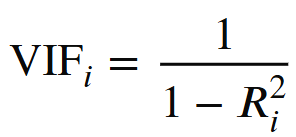

In [47]:
# Cálculo de Factor de Inflación de la Varianza
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Definimos las variables X del calculo y el intercepto para que no pase por el origen
x_vif = datos[['brix', 'ph_inicial', 'temperatura_c','brix_ph']].copy()
x_vif['intercepto'] = 1 #El cálculo requiere el intercepto
vif = pd.Series([variance_inflation_factor(x_vif.values,i) for i in range(x_vif.shape[1])], index=x_vif.columns).round(3)

In [48]:
print(vif)

brix              21.523
ph_inicial         9.641
temperatura_c      1.001
brix_ph           29.377
intercepto       326.228
dtype: float64


**Interpretación**

Existe multicolinealidad inducida por la ingeniería de atributos (adición de la columna brix_pH).

* **Brix (21.52) y Brix_ph (29.37):** Están totalmente solapados. Un VIF > 10 indica que estas variables comparten casi la misma información. Al ser el ratio una función lineal/directa del Brix, el modelo no sabe a cuál de las dos asignarle la "culpa" del rendimiento de etanol.

* **pH_inicial (9.64):** Está en el límite de la zona de peligro (10). Su varianza ya está empezando a verse afectada por la presencia del ratio.

* **Temperatura (1.001):** Es la única variable ortogonal y limpia. No tiene relación con las demás.

## **Matriz de Correlación**

In [49]:
correlacion = datos[numericos].corr(method='pearson')

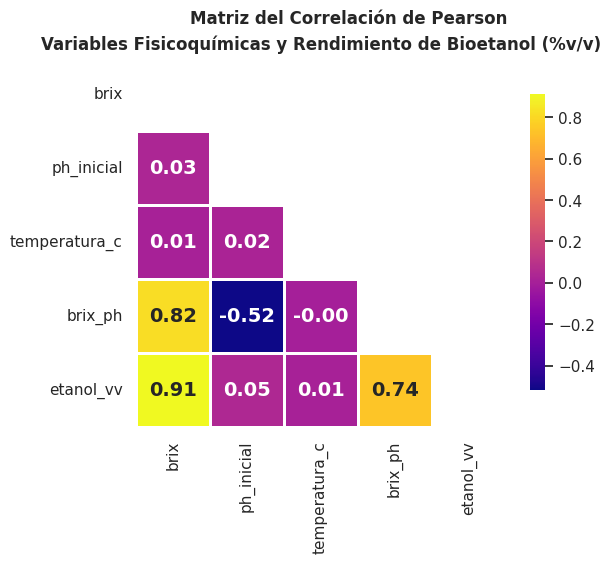

In [50]:
with sns.axes_style('white'):
  mascara = np.zeros_like(correlacion)
  mascara[np.triu_indices_from(mascara)]=True
  sns.heatmap(correlacion, annot=True, annot_kws={'fontsize':14, 'fontweight':'bold'}, fmt='.2f', cmap='plasma',mask=mascara,\
              cbar_kws={'shrink':0.8}, linewidths=0.9, square=True)
  plt.title("Variables Fisicoquímicas y Rendimiento de Bioetanol (%v/v)", fontsize=12, fontweight='bold')
  plt.suptitle("Matriz del Correlación de Pearson", fontsize=12, fontweight='bold')

**Interpretación**


La matriz de correlación revela una multicolinealidad inducida significativa entre el Brix y el Ratio ($r = 0.82$). Aunque el ratio brix_ph posee un alto poder predictivo ($r = 0.74$), su redundancia con el Brix sugiere que, en modelos lineales, el ratio actúa más como un factor de dispersión que como un optimizador, lo que explica la bimodalidad observada en los residuos. No obstante el Brix ($r = 0.91$) da correlación positiva fuerte, consolidándose como el predictor crítico del modelo mientras que pH ($r = 0.05$) y Temperatura ($r =0.01$) presentan asociaciones lineales nulas o despreciables.




## **Modelos y Diagnóstico**

Esta disparidad en los coeficientes justifica la **Ingeniería de Características**: al integrar el ratio **`brix_ph`**, buscamos extraer la varianza que el pH no logra explicar de forma aislada. La convergencia entre estos coeficientes y el análisis de varianza previo asegura que el dataset está listo para el entrenamiento, eliminando redundancias innecesarias.

### **Extracción - Transformación - Carga (ETL)**

In [51]:
# Importamos librerias de transformación a binarios variables categóricas
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [52]:
# Variables de independientes --> X
X = datos.drop('etanol_vv', axis=1)

In [53]:
# Variable dependiente o Target --> y
y = datos['etanol_vv']

In [54]:
# Validamos la función de ColumnTransformer y OneHotEncoder
procesamiento = ColumnTransformer(
    transformers = [
        ('cat',OneHotEncoder(handle_unknown='ignore', sparse_output=False), #Que ignore datos desconocidos y los datos de salida no sean dispersos.
        categoricos)], #La lista de las variables categóricas
        remainder='passthrough') #Permita el flujo de las variables restantes (numéricas)

In [55]:
# Imprimimos la configuración de procesamiento de las variables categóricas
procesamiento

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['provincia', 'variedad'])])

In [56]:
# Codificamos las variables categóricas con la configuración preestablecida.
X_procesada = procesamiento.fit_transform(X)

In [57]:
# Extraemos los nombres de las columnas procesadas.
name_cols = procesamiento.get_feature_names_out()

In [58]:
# Sobreescribimos nuestras variables independientes (X) como DataFrame con el nombre de las columnas extraidas.
X = pd.DataFrame(X_procesada, columns=name_cols)

In [59]:
# Visualizamos la codificación binaria de las variables categóricas
X.head()

,cat__provincia_esmeraldas,cat__provincia_guayas,cat__provincia_los_rios,cat__provincia_manabi,cat__variedad_ccn_51,cat__variedad_nacional,remainder__brix,remainder__ph_inicial,remainder__temperatura_c,remainder__brix_ph
0,1.0,0.0,0.0,0.0,0.0,1.0,15.7,3.52,26.2,4.460227
1,0.0,0.0,1.0,0.0,1.0,0.0,26.1,4.52,26.0,5.774336
2,1.0,0.0,0.0,0.0,0.0,1.0,22.2,5.44,36.5,4.080882
3,0.0,0.0,1.0,0.0,0.0,1.0,19.8,5.05,26.0,3.920792
4,0.0,0.0,1.0,0.0,0.0,1.0,11.8,5.26,26.4,2.243346


In [60]:
# Inspeccionamos las dimensiones del dataset con el que entrenaremos los modelos XGBoost y RandomForest
print(f"El total de columnas de las variables X posterior a transformación de datos categóricos es: {X.shape[1]}")

El total de columnas de las variables X posterior a transformación de datos categóricos es: 10


**División de datos X & y**

In [61]:
# Preparamos las variables de entranamiento y prueba.
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42 )

**Entrenamiento (n=800):** Es una base sólida para que el algoritmo aprenda la jerarquía del Brix que vimos en el ANOVA.

**Prueba (n=200):** Es el "examen final" donde validaremos si el modelo realmente puede predecir el etanol_vv en muestras nuevas de Guayas o Los Ríos.

**Escalado de variables X & y**

In [62]:
ss = StandardScaler() # Validamos

In [63]:
# Nuevas variables numéricas escaladas excluyendo el target (y)
numericos_vars = ['remainder__brix','remainder__ph_inicial', 'remainder__temperatura_c','remainder__brix_ph']

In [64]:
# Escalamos las variable X Train
X_train_ss = X_train.copy() # Hacemos copia del x Train original
X_train_ss[numericos_vars] = ss.fit_transform(X_train[numericos_vars])

In [65]:
# Escalamos las variable en X Test
X_test_ss = X_test.copy() # Hacemos copia del X Test original
X_test_ss[numericos_vars] = ss.transform(X_test[numericos_vars])

In [66]:
# Importamos los modelos
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor as xgb
# Importamos la KFold - Validación Cruzada
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
# Metricas
from sklearn.metrics import mean_squared_error
from yellowbrick.regressor import PredictionError
from yellowbrick.regressor import ResidualsPlot
import shap
from sklearn.metrics import mean_absolute_error

**KFold (Validación Cruzada)**

In [67]:
# Definimos la Validación Cruzada o KFold
vc = KFold(n_splits=5, shuffle=True, random_state=42)

### **Modelo RandomForestRegressor**

In [68]:
# Instaciamos el Modelo RandomForest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [69]:
# Ejecutamos validación cruzada --> exactitud (accuracy)
accuracy = cross_val_score(modelo_rf,
                           X = X_train_ss,
                           y = y_train,
                           cv = vc,
                           scoring = 'r2')

**Robustez del Modelo:** "Se implementó una validación cruzada de 5 pliegues (5-Fold Cross-Validation) con aleatorización previa (shuffle). Esta técnica mitiga el sesgo de selección y asegura que la capacidad predictiva del algoritmo sea consistente a lo largo de toda la variabilidad química del mucílago, independientemente de la distribución original de las muestras.

In [70]:
# Imprimimos la validación cruzada del modelo
print(f"R2 promedio (CV): {np.mean(accuracy):.2f} +/- {np.std(accuracy):.2f}")

R2 promedio (CV): 0.80 +/- 0.02


**Interpretación**

El algoritmo de Bosque Aleatorio alcanzó un coeficiente de determinación promedio de $R
2=0.80±0.02$ mediante validación cruzada. Aunque este valor es marginalmente inferior al modelo lineal inicial, representa una capacidad de generalización superior al mitigar el sesgo inducido por la multicolinealidad de los predictores. La baja varianza entre pliegues (σ=0.02) ratifica la estabilidad del motor de inferencia de este pipeline ante la heterogeneidad de las muestras de mucílago.

**Nota**

El 20% restante de la varianza probablemente se deba a factores que no estamos midiendo (actividad enzimática específica de la levadura, tipo de inóculo o variaciones en el tiempo de fermentación, entre otros).

**Optimización con RandomizedSearchCV**

In [71]:
# Importamos la libreria
from sklearn.model_selection import RandomizedSearchCV

# Definición de hiperparámetros
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],         # Controla la bimodalidad (evita memorización)
    'min_samples_split': [2, 5, 10],        # Robustez ante el ruido del pH
    'min_samples_leaf': [1, 2, 4],          # Suaviza las predicciones
    'max_features': ['sqrt', 'log2', None]}  # Mitiga la multicolinealidad del Brix_ph

In [72]:
# Configuración del RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=modelo_rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=vc,
    scoring='r2',
    random_state=42,
    n_jobs=-1)          # Usa todos los núcleos de su procesador

In [73]:
#Entrenamiento del modelo optimizado
random_search_rf.fit(X_train_ss, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestRegressor(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2')

In [96]:
# Visualizamos los 5 primeros resultados de RadomizedSearchCV
pd.DataFrame(random_search_rf.cv_results_).head().head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.474639,0.011961,0.020351,0.001012,100,5,4,None,30,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.781852,0.794633,0.830291,0.829982,0.772163,0.801784,0.024222,14
1,4.073486,0.819797,0.112883,0.029582,500,2,1,None,None,"{'n_estimators': 500, 'min_samples_split': 2, ...",0.782087,0.781533,0.830476,0.831294,0.773766,0.799831,0.025527,17
2,0.601213,0.008790,0.022427,0.000854,100,2,1,None,10,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.779943,0.780953,0.828402,0.826909,0.771935,0.797628,0.024720,19
3,0.899275,0.022365,0.060881,0.008441,300,5,4,sqrt,None,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.791632,0.803544,0.833056,0.829267,0.784426,0.808385,0.019610,6
4,0.299072,0.006097,0.021835,0.001524,100,10,4,log2,30,"{'n_estimators': 100, 'min_samples_split': 10,...",0.792822,0.799042,0.835053,0.822462,0.781055,0.806087,0.019796,13


In [75]:
# Imprimimos el mejor R2
print(f"Mejor R2: {random_search_rf.best_score_:.2f}")

Mejor R2: 0.81


In [76]:
# Imprimimos los mejores parámetros para el modelo RandomForest
print(f"Mejores parámetros para el modelo RandomForest: \n\n{random_search_rf.best_estimator_}")

Mejores parámetros para el modelo RandomForest: 

RandomForestRegressor(max_features='sqrt', min_samples_split=10,
                      n_estimators=200, random_state=42)


**Conlusión de Optimización**

Mediante RandomizedSearchCV, se determinó que la configuración óptima para la predicción de etanol_vv consiste en un ensamble de 200 árboles con una estrategia de selección de características de tipo raíz cuadrada (sqrt). Esta configuración permitió alcanzar un $R^2$ de 0.81, demostrando que la reducción del espacio de características por nodo es la estrategia más efectiva para gestionar la colinealidad entre el Brix y el pH, superando las limitaciones de los modelos lineales tradicionales ante la bimodalidad de los residuos.


**Gráfica de Importancias de Variables - RandomForest**

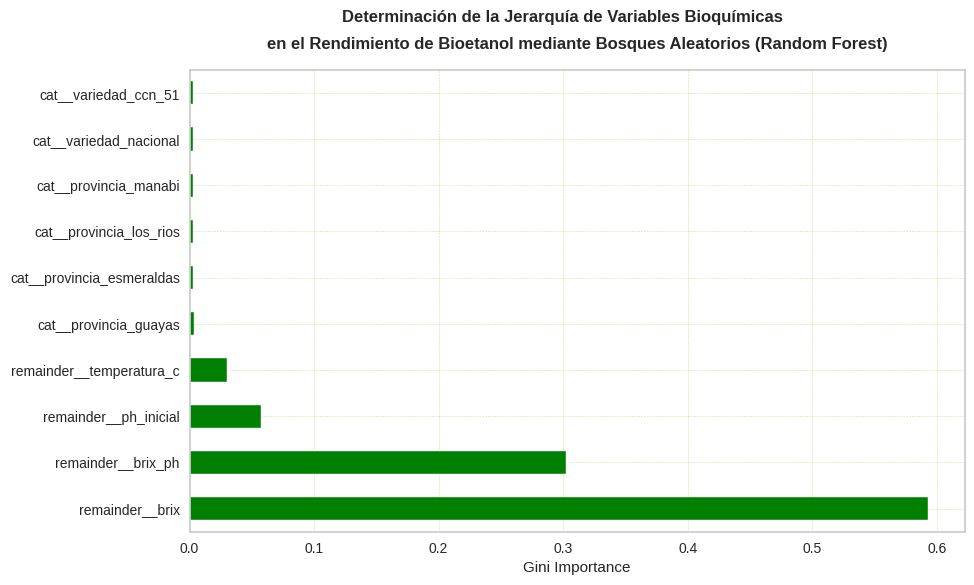

In [77]:
# 1. Extraer el mejor modelo del objeto de búsqueda
best_rf = random_search_rf.best_estimator_

# 2. Obtener las importancias y asociarlas a los nombres de las columnas
importancias = pd.Series(best_rf.feature_importances_, index=X_train_ss.columns).sort_values(ascending=False)

# 3. Graficar para el documento
plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='green')
plt.suptitle('Determinación de la Jerarquía de Variables Bioquímicas ', fontsize=12, fontweight='bold')
plt.title('en el Rendimiento de Bioetanol mediante Bosques Aleatorios (Random Forest)',fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Gini Importance') # Representa el decremento medio de la impureza (varianza) aportado por cada predictor.
plt.grid(zorder=0, ls='--', lw=0.4, color='yellowgreen', alpha=0.5)
plt.show()

**Interpretación de Gráfico de Variables Importantes**

Tras la optimización, se procedió a la extracción de las Importancias de Gini del mejor estimador (best_estimator_). Este análisis jerárquico permite validar que el modelo no solo depende de la carga inicial de azúcares (Brix), sino que integra de manera efectiva las interacciones químicas capturadas por el ratio y las variables categóricas, proporcionando una visión multidimensional del proceso fermentativo.

### **XGBoost - Regressor**





In [78]:
# Definir el modelo XGBoost
modelo_xgb = xgb(objective='reg:squarederror', random_state=42)

# Espacio de búsqueda específico para Boosting
param_dist_xgb = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1], # Clave para evitar el sobreajuste
    'max_depth': [3, 5, 7],             # Árboles más simples que en RF
    'subsample': [0.7, 0.8, 0.9],       # Entrenamiento estocástico
    'colsample_bytree': [0.7, 0.8, 0.9]} # Similar al max_features del RF

In [79]:
# Ejecutar la búsqueda
random_search_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=vc,
    scoring='r2',
    n_jobs=-1,
    random_state=42)

In [80]:
random_search_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=Non...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 500, 1000],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='r2')

In [95]:
# Visualizamos los 5 primeros resultados de RadomizedSearchCV
pd.DataFrame(random_search_xgb.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_max_depth,param_learning_rate,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.765717,0.064497,0.017597,0.003873,0.7,1000,7,0.01,0.7,"{'subsample': 0.7, 'n_estimators': 1000, 'max_...",0.772769,0.776463,0.823878,0.823137,0.767541,0.792758,0.025268,9
1,0.462583,0.013743,0.011860,0.004343,0.7,1000,3,0.01,0.7,"{'subsample': 0.7, 'n_estimators': 1000, 'max_...",0.784838,0.808375,0.839232,0.828208,0.781867,0.808504,0.022813,2
2,1.558306,0.234314,0.022249,0.009201,0.9,1000,5,0.10,0.8,"{'subsample': 0.9, 'n_estimators': 1000, 'max_...",0.754782,0.766845,0.801150,0.796589,0.747339,0.773341,0.021802,16
3,1.069469,0.028902,0.012072,0.000301,0.8,1000,5,0.10,0.9,"{'subsample': 0.8, 'n_estimators': 1000, 'max_...",0.740821,0.764477,0.794842,0.815311,0.741197,0.771329,0.029573,17
4,0.993119,0.018001,0.009795,0.000515,0.8,500,7,0.10,0.9,"{'subsample': 0.8, 'n_estimators': 500, 'max_d...",0.755388,0.773505,0.815313,0.805408,0.741237,0.778170,0.028377,14


In [82]:
# Imprimimos el mejor R2
print(f"Mejor R2: {random_search_xgb.best_score_:.2f}")

Mejor R2: 0.81


In [83]:
# Imprimimos los mejores parámetros para el modelo RandomForest
print(f"Mejores parámetros para el modelo XGBRegressor: \n\n{random_search_xgb.best_estimator_}")

Mejores parámetros para el modelo XGBRegressor: 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)


**Gráfica de Importancia de Variables - XGBoost**

In [84]:
from xgboost import plot_importance # La libreria XGBoost cuenta con gráficas

Text(0, 0.5, 'Variables')

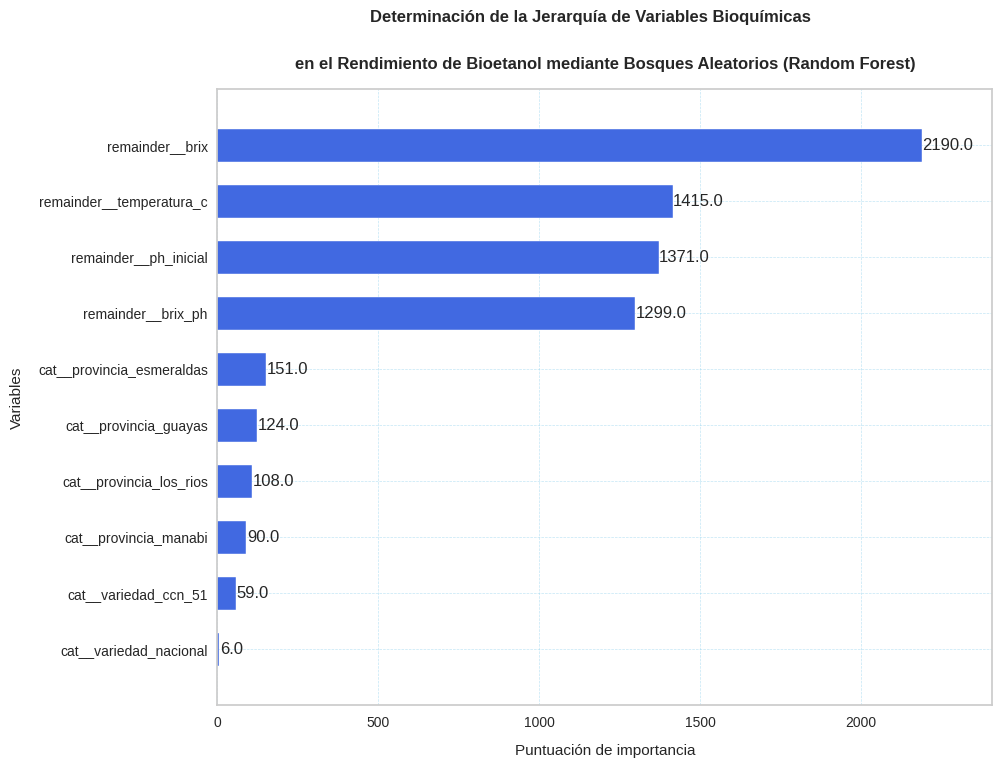

In [85]:
# 1. Extraer el mejor modelo (ya entrenado)
best_xgb = random_search_xgb.best_estimator_

# 2. Configurar el gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(best_xgb,
                   max_num_features=10,
                   ax=ax,
                   height=0.6,
                   color='royalblue')
plt.suptitle('Determinación de la Jerarquía de Variables Bioquímicas ', fontsize=12, fontweight='bold')
plt.title('en el Rendimiento de Bioetanol mediante Bosques Aleatorios (Random Forest)',fontsize=12, fontweight='bold', pad=15)
plt.grid(zorder=0, ls='--',lw=0.5, color='skyblue', alpha=0.5)
plt.xlabel('Puntuación de importancia', labelpad=10)
plt.ylabel('Variables', labelpad=10)

### **Métricas de Desempeño**

**Gráfica de Predicción de Error - RandomForest**

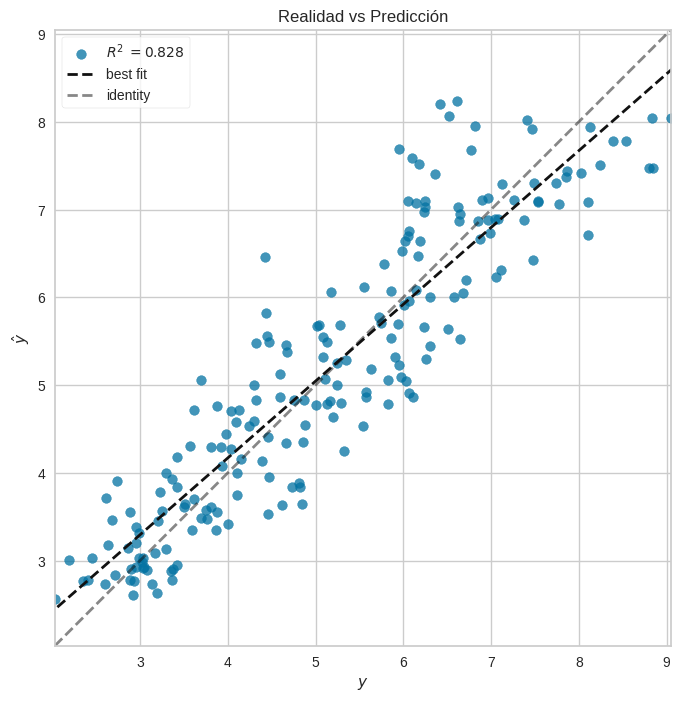

<Axes: title={'center': 'Realidad vs Predicción'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [86]:
fig = plt.figure(figsize=(8,8))
pe = PredictionError(modelo_rf, title='Realidad vs Predicción')
pe.fit(X_train_ss,y_train)
pe.score(X_test_ss,y_test)
pe.poof()

**Gráfica de Predicción de Error - XGBoost**

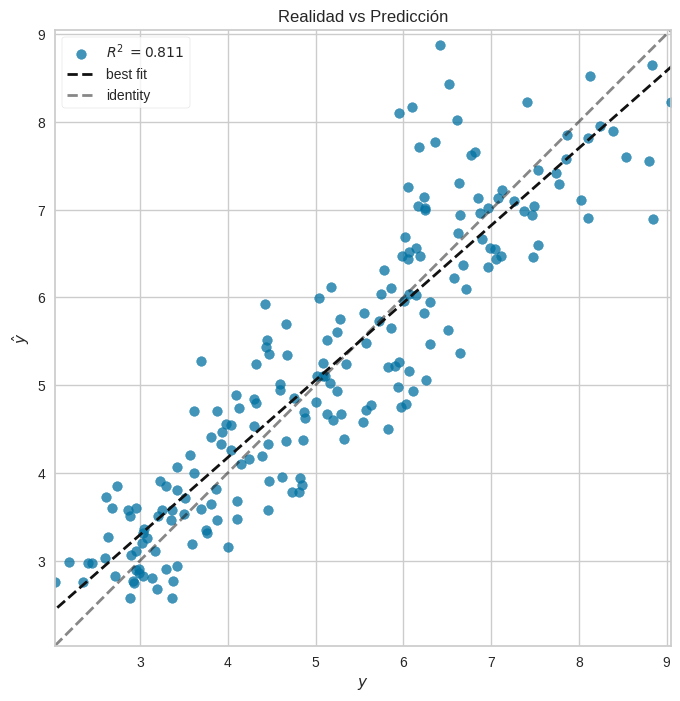

<Axes: title={'center': 'Realidad vs Predicción'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [87]:
fig = plt.figure(figsize=(8,8))
pe = PredictionError(modelo_xgb, title='Realidad vs Predicción')
pe.fit(X_train,y_train)
pe.score(X_test,y_test)
pe.poof()

**Gráfico Residual del Modelo RandomForest**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


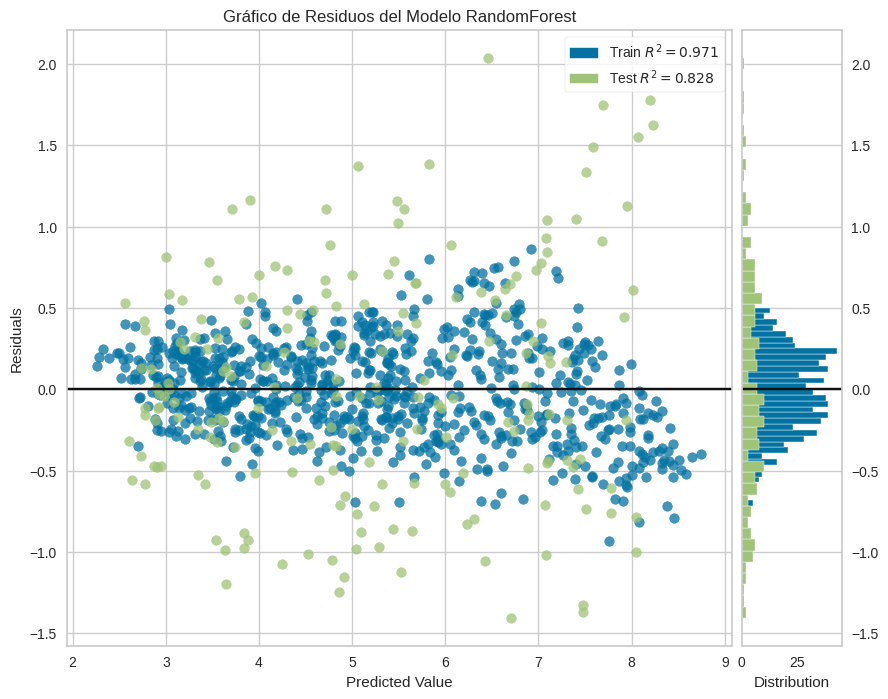

<Axes: title={'center': 'Gráfico de Residuos del Modelo RandomForest'}, xlabel='Predicted Value', ylabel='Residuals'>

In [88]:
fig = plt.figure(figsize=(10,8))
rplot = ResidualsPlot(modelo_rf, title='Gráfico de Residuos del Modelo RandomForest')
rplot.fit(X_train_ss,y_train)
rplot.score(X_test_ss,y_test)
rplot.show()

**Interpretación Gráfico Residual**

La nube azul de entrenamiento es mucho más ancha ($R
2=0.971$). El bosque aleatorio no intenta forzar el ajuste tanto, lo que lo hace un poco más rudo pero estable.

Sin embargo, en el Test hay una ligera tendencia de **embudo** o **heterocedasticidad** que significa que el error parece aumentar ligeramente a medida que el valor predicho de etanol sube.

**Gráfico Residual del Modelo XGBoost**

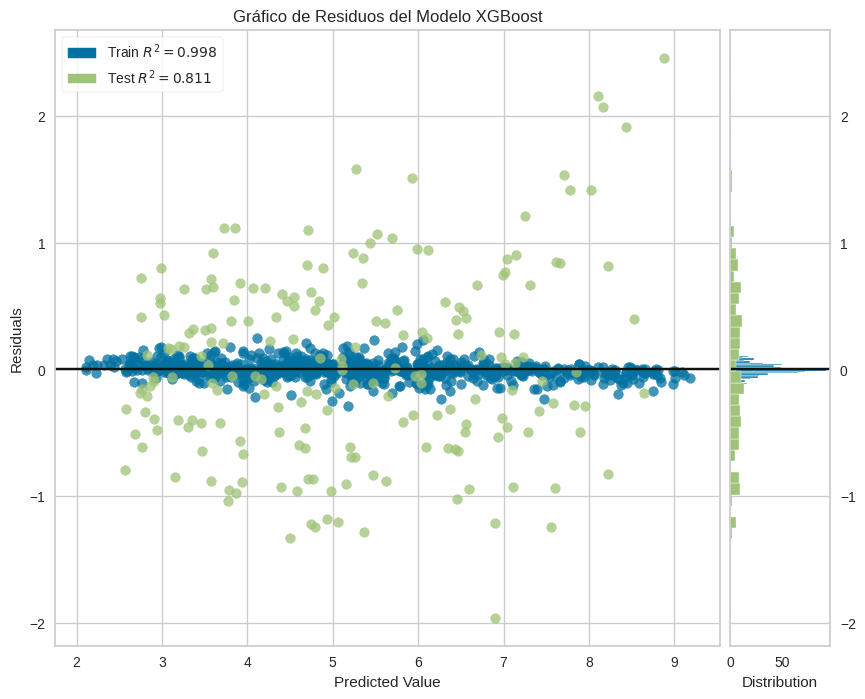

<Axes: title={'center': 'Gráfico de Residuos del Modelo XGBoost'}, xlabel='Predicted Value', ylabel='Residuals'>

In [89]:
fig = plt.figure(figsize=(10,8))
rplot = ResidualsPlot(modelo_xgb, title='Gráfico de Residuos del Modelo XGBoost')
rplot.fit(X_train,y_train)
rplot.score(X_test,y_test)
rplot.show()

**Interpretación Gráfico Residual**

Observe la nube azul (Train). Está extremadamente comprimida cerca del cero ($R2 = 0.998$). Esto indica que el modelo secuencial **aprendió** casi perfectamente la estructura de sus 1000 datos.
En el Test (puntos verdes), los residuos están más dispersos pero mantienen una distribución más simétrica respecto al eje cero que el Random Forest.

 **Raíz del Error Cuadrático Medio (RMSE) - RandomForest**

In [90]:
# 1. Realizar predicciones con el mejor estimador
y_pred = random_search_rf.best_estimator_.predict(X_test_ss)

# 2. Calcular el MSE y luego la raíz cuadrada (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"RMSE del RandomForest: {rmse:.4f}")

RMSE del RandomForest: 0.6733


**Validación de la Magnitud del Error**

El modelo optimizado presenta una Raíz del Error Cuadrático Medio (RMSE) de $0.6731$. Esta métrica, expresada en las unidades reales de producción de bioetanol (% v/v), confirma una alta precisión en la estimación. La magnitud del error es técnicamente aceptable para la estandarización de procesos de aprovechamiento de mucílago de cacao, validando la robustez de los predictores bioquímicos seleccionados en la arquitectura del bosque aleatorio.

 **Raíz del Error Cuadrático Medio (RMSE) - XGBoost**

In [91]:
# 1. Predicciones con el mejor modelo de XGBoost
y_pred_xgb = random_search_xgb.best_estimator_.predict(X_test)

# 2. Cálculo de métricas de error
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print(f"RMSE del XGBoost: {rmse_xgb:.4f}")

RMSE del XGBoost: 0.6649


**Validación de la Magnitud del Error**

El modelo optimizado mediante Gradient Boosting (XGBoost) alcanzó un RMSE de 0.6649. Esta métrica cuantifica la desviación típica de los residuos en unidades de concentración de bioetanol (% v/v).

**Error Medio Absoluto (MAE) + SHAP (Beeswarm Plot) - RandomForest**


- El MAE es el "error promedio real". A diferencia del RMSE, no penaliza tan fuerte los valores atípicos; simplemente mide la distancia promedio entre la predicción y la realidad.
- Los gráficos Beeswarm son los más potentes porque muestran la direccionalidad y la magnitud del impacto de cada variable.

MAE RandomForest: 0.5562


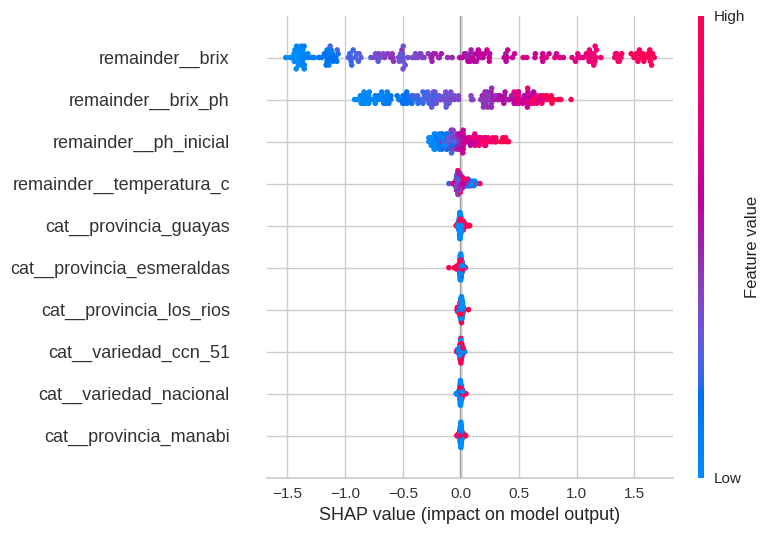

In [92]:
# 1. Calcular MAE
mae_rf = mean_absolute_error(y_test, y_pred)
print(f"MAE RandomForest: {mae_rf:.4f}")

# 2. Configurar SHAP (usando el TreeExplainer para RandomForest)
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_ss)

# 3. Gráfico Beeswarm (Distribución de Impacto)
plt.figure()
shap.summary_plot(shap_values, X_test_ss)

**Error Medio Absoluto (MAE) + SHAP (Beeswarm Plot) - XGBoost**

MAE XGBoost: 0.5455


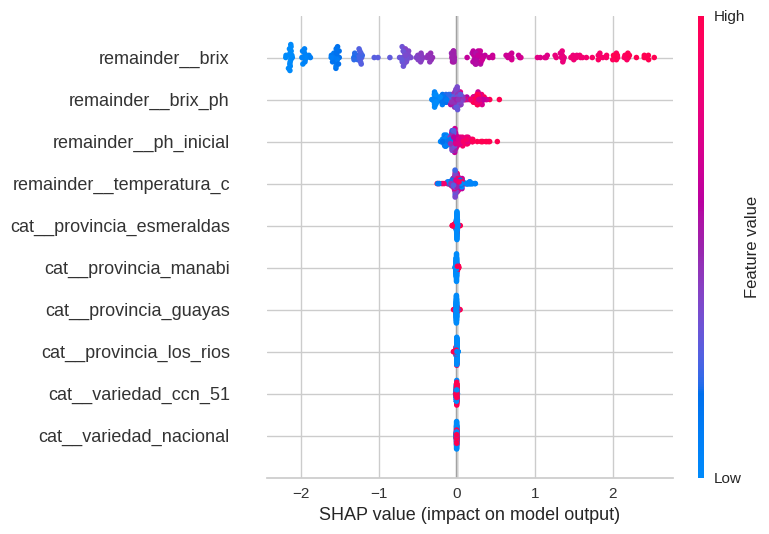

In [93]:
# 1. Calcular MAE
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print(f"MAE XGBoost: {mae_xgb:.4f}")

# 2. Configurar SHAP (usando el TreeExplainer para XGBoost)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# 3. Gráfico Beeswarm (Distribución de Impacto)
plt.figure()
shap.summary_plot(shap_values, X_test)

**Interpretación**

Con un MAE de 0.5455 (XGBoost) y 0.5562 (Random Forest), el sistema detecta un error de apenas ≈0.55% v/v de alcohol.

**Valor Operativo:** Para un productor, esto significa que si el modelo predice un 8% de rendimiento, el valor real en el destilador estará muy probablemente entre 7.45% y 8.55%. Es un margen de error sumamente bajo para procesos biológicos.

**Conclusión y Selección de Algoritmo**



Tras el proceso de optimización estocástica, se selecciona el algoritmo **XGBoost** como el núcleo predictivo para este proyecto. Su capacidad para minimizar la función de pérdida cuadrática resultó con un **RMSE** de $0.6649$ y un error promedio real (**MAE**) de $0.5455$, ofreciendo la mayor fiabilidad en la estimación del rendimiento volumétrico de etanol, superando la capacidad de ajuste del Bosque Aleatorio convencional.

La proximidad entre el RMSE y el MAE del modelo XGBoost sugiere una distribución de errores consistente y una baja sensibilidad a valores atípicos, confirmando que la arquitectura del modelo es robusta para la estimación de rendimientos en condiciones de variabilidad bioquímica del mucílago de cacao.